# Text Clustering and Topic Modeling

- Text Clustering aims to group similar texts based on their semantic content, meaning, and relationships.
- topic modeling is the process to discover (abstract) topics that appear in large collections of textual data.


In [1]:
pip install bertopic datasets datamapplot

## ArXiv’s Articles: Computation and Language

In [2]:
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

d:\2026-courses\LLMs-Handson\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset.features

{'Titles': Value('string'),
 'Abstracts': Value('string'),
 'Years': Value('int64'),
 'Categories': Value('string')}

In [4]:
# Extract metadata
abstracts = dataset["Abstracts"]
titles = dataset["Titles"]

## A common pipeline for text Clustering
Although there are many methods for text clustering, from graph-based neural networks to centroid-based clustering techniques, a common pipeline that has gained popularity involves three steps and algorithms:
- Convert the input documents to embeddings with an embedding model.
- Reduce the dimensionality of embeddings with a dimensionality reduction model.
- Find groups of semantically similar documents with a cluster model.


### Step1: Embedding Documents
- The first step is to convert our textual data to embeddings
- Choosing embedding models optimized for semantic similarity tasks is especially important for clustering as we attempt to find groups of semantically similar documents. Fortunately, most embedding models at the time of writing focus on just that, semantic similarity.
- we will use gte model (General Text Embedding): https://huggingface.co/thenlper/gte-small


In [5]:
from sentence_transformers import SentenceTransformer

# Create an embedding for each abstract
embedding_model= SentenceTransformer("thenlper/gte-small")
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4234.03it/s]
BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 1405/1405 [01:01<00:00, 22.90it/s]


In [6]:
embeddings.shape

(44949, 384)

- Each embedding has 384 values that together represent the semantic representation of the document.
- We view the embedding as the features that we want to cluster

### Step2: Reducing the Dimensinality of the embedding
- Before we cluster the embeddings, we will first need to take their high dimensionality into account
- As the number of dimensions increases, there is an exponential growth in the number of possible values within each dimension.
- Finding all subspaces within each dimension becomes increasingly complex.
- high-dimensional data can be troublesome for many clustering techniques as it gets more difficult to identify meaningful clusters.
- 

In [7]:
from umap import UMAP
#We reduce the input embeddings from 384 dimenions to 5 dimenions

umap_model= UMAP(n_components=5, min_dist=0.0, metric='cosine', random_state=42)
reduced_embeddings = umap_model.fit_transform(embeddings)

d:\2026-courses\LLMs-Handson\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


- n_components parameter: Decide the shape of the lower-dimensional space, namely 5 dimensions. Generally, values between 5 and 10 work well to capture high-dimensional global structures.
- The min_dist parameter: the minimum distance between embedded points. We are setting this to 0 as that generally results in tighter clusters.
- set metric to 'cosine' as Euclidean-based methods have issues dealing with high-dimensional data.
- Note that setting a random_state in UMAP will make the results reproducible across sessions but will disable parallelism and therefore slow down training.

### Step3: Cluster the Reduced Embeddings
- Although a common choice is a centroid-based algorithm like k-means, which requires a set of clusters to be generated, we do not know the number of clusters beforehand.
- Instead, a density-based algorithm freely calculates the number of clusters and does not force all data points to be part of a cluster
- A common density-based model is Hierarchical Density-Based Spatial Clustering of Applications with Noise (HDBSCAN).
- HDBSCAN is a hierarchical variation of a clustering algorithm called DBSCAN that allows for dense (micro)-clusters to be found without having to explicitly specify the number of clusters.
- As a density-based method, HDBSCAN can also detect outliers in the data, which are data points that do not belong to any cluster.
- These outliers will not be assigned or forced to belong to any cluster. In other words, they are ignored.


In [8]:
from hdbscan import HDBSCAN
# We fit the model and extract the clusters
hdbscan_model= HDBSCAN(
    min_cluster_size=10,
    metric='euclidean',
    cluster_selection_method='eom',
).fit(reduced_embeddings)


In [9]:
clusters = hdbscan_model.labels_
# How many clusters were found?
len(set(clusters))

544

With HDBSCAN, we generated 544 clusters in our dataset. To create more clusters, we will need to reduce the value of min_cluster_size as it represents the minimum size that a cluster can take.

#### Inspecting Clusters


In [10]:
# Manually inspect the clusters 0
import numpy as np
cluster = 0

for index in np.where(clusters == cluster)[0]:
    print(abstracts[index] + "... \n")

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written form of
ASL. Second, we pass the output to the WebSign Plug-in to play the sign.
Contributions of this work are the use of a new couple of language English/ASL
and an improvement of statistical machine translation based on string matching
thanks to Jaro-distance.
... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign language
gestures. We discuss the relevance and interest of a motor theory of perception
in sign language communication. According to th

Next, we reduce our embeddings to 2-dimensions so that we can plot them and get a rough understanding of the generated clusters.

In [11]:
import pandas as pd

# Reduce 384-dimensional embeddings to 2 dimensions for easier visualization
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric='cosine', random_state=42
).fit_transform(embeddings)

# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

# Select outliers and non-outliers (clusters)
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

d:\2026-courses\LLMs-Handson\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
df.head()

,x,y,title,cluster
0,4.327925,12.115063,Introduction to Arabic Speech Recognition Usin...,496
1,4.301742,12.100230,Arabic Speech Recognition System using CMU-Sph...,496
2,4.417060,11.390985,On the Development of Text Input Method - Less...,-1
3,3.019056,9.954437,Network statistics on early English Syntax: St...,446
4,4.184937,8.914654,Segmentation and Context of Literary and Music...,-1


(np.float64(-7.331094360351562),
 np.float64(11.749896621704101),
 np.float64(-2.476739376783371),
 np.float64(18.255715936422348))

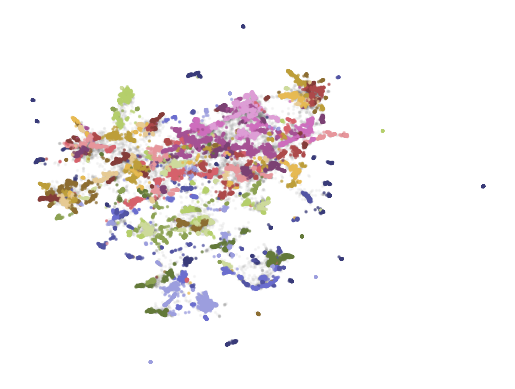

In [13]:
import matplotlib.pyplot as plt

# Plot outliers and non-outliers seperately
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap='tab20b'
)

plt.axis('off')
# plt.savefig("matplotlib.png", dpi=300)  # Uncomment to save the graph as a .png

This is visually appealing but does not yet allow us to see what is happening inside the clusters. Instead, we can extend this visualization by going from text clustering to topic modeling.

## From Text Clustering to Topic Modeling
- In text clustering, we can find the clusters but if we want to give a title to this cluster we need to inspect elements manually and analyze the keywords.
- To solve this issue and find the themese automatically, we need topic modeling
- Topic modeling involves finding a set of keywords or phrases that best represent and capture the meaning of the topic.
- In this section, we'll extend the text clustering into the realm of topic modeling through a highly modular text clustering and topic modeling framework.

### BERTopic: A Modular Topic Modeling Framework
- BERTopic is a topic modeling technique that leverages clusters of semantically similar texts to extract various types of topic representations.
- Two steps
  - First, we follow the same procedure used in text clustering: Embed + Reduce dimension + Cluster
  - Second, it models a distribution over words in the corpus’s vocabulary by leveraging a classic method, namely bag-of-words.
    - Bag-of-words: Count the number of times each word appears in a document. The resulting representation could be used to extract the most frequent words inside a document. (see img11)
    - There are two caveats, however:
        - First, this is a representation on a document level and we are interested in a cluster-level perspective.
        - To address this, the frequency of words is calculated within the entire cluster instead of only the document (see img12)
        - Second, stop words like “the” and “I” tend to appear often in documents and provide little meaning to the actual documents.

**Solution**: BERTopic uses a class-based variant of term frequency–inverse document frequency (c-TF-IDF) to put more weight on words that are more meaningful to a cluster and put less weight on words that are used across all clusters.

- Each word in the bag-of-words, the c-TF in c-TF-IDF, is multiplied byb the IDF value of each word.
- The IDF value is calculated by taking the logarithm of the average frequency of all wodrs across all clusters divided by the total frequency of each word.
 - The result is a weight (“IDF”) for each word that we can multiply with their frequency (“c-TF”) to get the weighted values (“c-TF-IDF”). See the img 14

 ### Second Part: CountVectorizer
 - Goal: convert Text into numbers
 - Count how many times each word appears

### Ful Pipeline
- Input: Set of Documents
- Step2: Embedding
- Step3: Clustering (UMAP+HDBSCAN)
- Step4: Merge Document per Cluster
- Step5: C-TF-IDF to know the importance of each word
- Ste6: Top words = Topic representation

Check the pipeline in img16

**Img17 shows that we can think of this modularity as building with Lego blocks; each part of the pipeline is completely replaceable with another, similar algorithm. Through this modularity, newly released models can be integrated within its architecture. As the field of Language AI grows, so does BERTopic!**

### The Modularity of BERTopic
The modularity of BERTopic has another advantage: it allows it to be used and adapted to different use cases using the same base model. For instance, BERTopic supports a wide variety of algorithmic variants:

- Guided topic modeling
- (Semi-)supervised topic modeling
- Hierarchical topic modeling
- Dynamic topic modeling
- Multimodal topic modeling
- Multi-aspect topic modeling
- Online and incremental topic modeling
- Zero-shot topic modeling

- Documentation: https://maartengr.github.io/BERTopic/getting_started/zeroshot/zeroshot.html
- GitHub Link: https://github.com/MaartenGr/BERTopic

**Run**: To run BERTopic with our ArXiv dataset, we can use our previously defined models and embeddings (although it is not mandatory):

In [14]:
from bertopic import BERTopic
# Train our model with our previously defined models
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(abstracts,embeddings)

2026-04-13 05:44:20,132 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-13 05:44:58,173 - BERTopic - Dimensionality - Completed ✓
2026-04-13 05:44:58,174 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-13 05:44:59,155 - BERTopic - Cluster - Completed ✓
2026-04-13 05:44:59,164 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-13 05:45:02,679 - BERTopic - Representation - Completed ✓


Let us start by exploring the topics that were created. The get_topic_info() method is useful to get a quick description of the topics that we found:

In [15]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,15787,-1_language_of_and_the,"[language, of, and, the, to, in, we, that, for...",[ Large Language Models (LLMs) have exhibited...
1,0,865,0_hate_offensive_toxic_detection,"[hate, offensive, toxic, detection, toxicity, ...",[ The goal of hate speech detection is to fil...
2,1,600,1_relation_extraction_re_relations,"[relation, extraction, re, relations, entity, ...",[ Sentence-level relation extraction mainly a...
3,2,384,2_summarization_abstractive_summary_summaries,"[summarization, abstractive, summary, summarie...",[ Existing multi-document summarization syste...
4,3,343,3_legal_court_law_case,"[legal, court, law, case, judgment, ljp, cases...","[ Legal case retrieval, which aims to retriev..."
...,...,...,...,...,...
539,538,10,538_pos_tagging_rmwe_mixed,"[pos, tagging, rmwe, mixed, tagger, icon, kann...",[ Part-of-speech (POS) tagging is a process o...
540,539,10,539_linking_biomedical_entity_bioel,"[linking, biomedical, entity, bioel, kb, medic...",[ Pre-trained language models induce dense en...
541,540,10,540_screening_reviews_systematic_slrs,"[screening, reviews, systematic, slrs, csmed, ...",[ With the proliferation of open-sourced Larg...
542,541,10,541_dataflow_df_smcalflow_dialogue,"[dataflow, df, smcalflow, dialogue, multiwoz, ...",[ SMCalFlow is a large corpus of semantically...


Each of these topics is represented by several keywords, which are concatenated with a “_” in the Name column. This Name column allows us to quickly get a feeling of what the topic is about as it shows the four keywords that best represent it.

We can inspect individual topics and explore which keywords best represent them with the get_topic function. For example, topic 0 contains the following keywords:

In [16]:
topic_model.get_topic(0)

[('hate', np.float64(0.022430846514312226)),
 ('offensive', np.float64(0.013718581057248875)),
 ('toxic', np.float64(0.008951398387797332)),
 ('detection', np.float64(0.007659810013659929)),
 ('toxicity', np.float64(0.007364790235434352)),
 ('abusive', np.float64(0.007189008149029763)),
 ('speech', np.float64(0.007037879016082796)),
 ('social', np.float64(0.006346378684649404)),
 ('online', np.float64(0.006174670550056353)),
 ('comments', np.float64(0.006152604870860771))]

We can use the find_topics() function to search for specific topics based on a search term. Let’s search for a topic about **topic modeling**:

In [17]:
topic_model.find_topics("topic modeling")

([9, 377, 256, -1, 457],
 [np.float64(0.9551190702694018),
  np.float64(0.9188324915766598),
  np.float64(0.9154176760326811),
  np.float64(0.9114833840018703),
  np.float64(0.9097264330550432)])

This returns that topic 9 has a relatively high similarity (0.95) with our search term. If we then inspect the topic, we can see that it is indeed a topic about topic modeling:

In [18]:
topic_model.get_topic(9)



[('topic', np.float64(0.041509693930896034)),
 ('topics', np.float64(0.02421569022613533)),
 ('lda', np.float64(0.013780288106540297)),
 ('latent', np.float64(0.00899491078836106)),
 ('dirichlet', np.float64(0.008552703292986946)),
 ('documents', np.float64(0.007296285261996232)),
 ('modeling', np.float64(0.007131215258293515)),
 ('document', np.float64(0.00709119206434081)),
 ('allocation', np.float64(0.006575331692258634)),
 ('coherence', np.float64(0.005221395665844627))]

Although we know that this topic is about topic modeling, let’s see if the BERTopic abstract is also assigned to this topic:

In [19]:
topic_model.topics_[titles.index('BERTopic: Neural topic modeling with a class-based TF-IDF procedure')]



9

## Tip
The modularity of BERTopic gives you a lot of choices, which can be overwhelming. For that purpose, the author created a best practices guide that goes through common practices to speed up training, improve representations, and more: https://maartengr.github.io/BERTopic/getting_started/best_practices/best_practices.html

## Visualization

In [20]:
# Visualize topics and documents
fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)

# Update fonts of legend for easier visualization
fig.update_layout(font=dict(size=16))

In [21]:
# Visualize barchart with ranked keywords
topic_model.visualize_barchart()

# Visualize relationships between topics
topic_model.visualize_heatmap(n_clusters=30)

# Visualize the potential hierarchical structure of topics
topic_model.visualize_hierarchy()

In [22]:
pip install nbformat

Note: you may need to restart the kernel to use updated packages.


## Adding a Special Lego Block
- The pipeline in BertTopic fast and modular, but it still represents a topic through a bag-of-words without taking into account semantic staructures.
- Bag-of-words can speed to generate a meaningful representation. We can use this first meaningful representation and tweak it using more powerful but slower techniques, like embedding models
- Solution: We can re-rank the initial distributions of words to improve the resulting representation (Check the image 18)
 - As a result, we can design a new lego block that takes in first topic represntation and spits out an improved representation.
 - In BERTopic, such reranker models are referred to as **representation models**.
 - A major benefit of this approach is that the optimization of topic representations only needs to be done as many times as we have topics.
 -  For instance, if we have millions of documents and a hundred topics, the representation block only needs to be applied once for every topic instead of for every document. Check the img 19
 
 Before we explore how we can use these representations blocks, firts we need to do two things
  - First: save our orginal topic representations.
  - Second, create a short wrapper that we can use to quickly visualize the differences in topic words to compare with and without representation models
 


In [23]:
# Save the original topic representations
from copy import deepcopy
original_topic_representations = deepcopy(topic_model.topic_representations_)

In [27]:
def topic_differences(model, original_topics, nr_topics=5):
    """Show the differences in topic representations between two models """
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):

        # Extract top 5 words per topic per model
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
        df.loc[len(df)] = [topic, og_words, new_words]

    return df



## KeyBERTInspired
- The first representation block that we are going to explore is KeyBERTInspired. 
- KeyBERTInspired is, as you might have guessed, a method inspired by the keyword extraction package, KeyBERT. 
- KeyBERT extracts keywords from texts by comparing word and document embeddings through cosine similarity.
- KeyBERTInspired uses c-TF-IDF to extract the most representative documents per topic by calculating the similarity between a document’s c-TF-IDF values and those of the topic they correspond to. 
- KeyBert Link: https://github.com/MaartenGr/KeyBERT


In [28]:
from bertopic.representation import KeyBERTInspired

# Update our topic representations using KeyBERTInspired

representation_model = KeyBERTInspired()
topic_model.update_topics(abstracts, representation_model=representation_model)


# show differences
topic_differences(topic_model, original_topic_representations)


,Topic,Original,Updated
0,0,hate | offensive | toxic | detection | toxicity,hate | hateful | language | offensive | twitter
1,1,relation | extraction | re | relations | entity,relation | relations | relational | extracting...
2,2,summarization | abstractive | summary | summar...,summarization | summarizing | summarizer | sum...
3,3,legal | court | law | case | judgment,law | judgments | cases | llms | summarization
4,4,tuning | lora | peft | parameters | parameter,finetuning | adapting | tuning | adaptive | op...


### Maximal marginal relevance
- With c-TF-IDF and KeyBERTInspired techniques, we still have significant redundancy in the resulting topic representation. For instance: summarization, summarizing, summarizer, etc.
- We can use maximal marginal relevance (MMR) to diversify our topic representations.
- MMR tries to find the keywords that are diverse from one another but still relate to the document they are compared to
- It does so by embedding a set of candidate keywords and iteratively calculating the next best keyword to add.
- Doing so requires setting a diversity parameter, which indicates how diverse keywords need to be.

In BERTopic, we use MMR to go from a set of initial keywords, let’s say 30, to a smaller but more diverse set of keywords, let’s say 10. It filters out redundant words and only keeps words that contribute something new to the topic representation.


In [30]:
from bertopic.representation import MaximalMarginalRelevance

## Update our topic representations to MaximalMarginalRelevance

representation_model = MaximalMarginalRelevance(diversity=0.5)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topic_representations)

,Topic,Original,Updated
0,0,hate | offensive | toxic | detection | toxicity,toxic | comments | hateful | platforms | cyber...
1,1,relation | extraction | re | relations | entity,re | relations | entities | distant | document
2,2,summarization | abstractive | summary | summar...,summarization | extractive | rouge | mds | sen...
3,3,legal | court | law | case | judgment,ljp | judicial | contracts | indian | retrieval
4,4,tuning | lora | peft | parameters | parameter,tuning | lora | peft | adapters | adaptation


The resulting topics demonstrate more diversity in their representations. For instance, topic 4 only shows one “summary”-like word and instead adds other words that might contribute more to the overall representation.

### Tip
- Both KeyBERTInspired and MMR are amazing techniques for improving the first of topic representations.
- KeyBERTInspired especially tends to remove nearly all stop words since it focuses on the semantic relationships between words and documents.